# Module 2 – Placement Prediction: Step-by-Step Preprocessing

### Topics covered
1. Train/Test Split
2. Missing-value analysis
3. Median imputation
4. Missing-indicator features
5. Label encoding of the target
6. Ordinal encoding of ordered features
7. One-hot encoding of nominal features
8. Feature scaling

**Important:** This notebook intentionally does **not** use `Pipeline` or `ColumnTransformer`.

The purpose is to let beginners see every preprocessing operation separately.

### Correct order

```text
Load Data
    ↓
Remove Duplicates
    ↓
Separate X and y
    ↓
Train/Test Split
    ↓
Missing Value Handling
    ↓
Categorical Encoding
    ↓
Feature Scaling
    ↓
ML Model
    ↓
Evaluation
```

**Golden rule:** Fit/learn every preprocessing rule using training data only. Then apply the learned rule to the test data.


In [59]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

print("Libraries imported successfully.")


Libraries imported successfully.


In [60]:
print("HELLO")

HELLO


## 2. LOAD THE PLACEMENTPREDICT DATASET

The slides use the PlacementPredict student placement dataset.

If your CSV is stored in another location, change only the path below.


In [61]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv(
    r'C:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\data\placement_predict_50k Dataset_final.csv'
)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (10000, 45)


,StudentID,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,...,Stream_Civil,Stream_ECE,Stream_EE,Stream_IT,Stream_Mechanical,Specialisation_DataScience,Specialisation_Embedded,Specialisation_Networking,Hostel_Yes,HistoryOfBacklogs_Yes
0,-0.540266,-1.159080,-1.064481,-1.137401,-1.035531,-0.998604,-1.056297,-1.380776,-0.850175,-1.021957,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,-1.215032,-0.277425,0.219222,-0.293950,-0.221499,-0.200163,-0.096825,0.003680,-0.307593,-0.169077,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.890055,0.623969,0.545035,0.285520,0.961391,0.686295,0.488827,0.883578,0.326435,0.516936,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.124963,0.637128,0.577616,0.729780,0.204596,0.516547,0.694428,0.545156,0.826342,0.609640,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
4,-0.494443,0.702924,1.085884,0.761973,1.279373,1.063511,1.261389,0.871272,0.960463,1.091703,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


## 3. BASIC DATASET UNDERSTANDING

Before preprocessing, check the number of rows, columns, data types and duplicate records.


In [62]:
# ============================================================
# 3. BASIC INSPECTION
# ============================================================

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nDuplicate rows:", df.duplicated().sum())


Shape: (10000, 45)

Data types:
StudentID                     float64
SGPA_Sem1                     float64
SGPA_Sem2                     float64
SGPA_Sem3                     float64
SGPA_Sem4                     float64
SGPA_Sem5                     float64
SGPA_Sem6                     float64
SGPA_Sem7                     float64
SGPA_Sem8                     float64
CGPA                          float64
AttendancePercent             float64
Internships                   float64
Projects                      float64
Workshops                     float64
Certifications                float64
Publications                  float64
AptitudeTestScore             float64
SoftSkillsRating              float64
CodingTestScore               float64
MockInterviewScore            float64
ExtraCurricular               float64
IsAnomaly                     float64
Salary Package                float64
CollegeTier                       str
CGPA_Tier                         str
Gender_Male       

## 4. REMOVE DUPLICATE ROWS

Duplicate records can give the same student information more influence during model training.

We remove exact duplicate rows before creating the train/test sets.


In [63]:
# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)

print("Rows before removing duplicates:", rows_before)
print("Rows after removing duplicates :", rows_after)
print("Duplicates removed             :", rows_before - rows_after)


Rows before removing duplicates: 10000
Rows after removing duplicates : 10000
Duplicates removed             : 0


## 5. SEPARATE FEATURES (X) AND TARGET (y)

`X` contains the input features.

`y` contains the value that we want to predict.

For this dataset, the target is `PlacementStatus`.

The target must **not** be imputed or scaled as an input feature.


In [64]:
print(df.columns.tolist())

['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'CollegeTier', 'CGPA_Tier', 'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']


In [65]:
# # ============================================================
# # 5. SEPARATE X AND y
# # ============================================================

# X = df.drop("", axis=1)
# y = df["PlacementStatus"]

# print("X shape:", X.shape)
# print("y shape:", y.shape)

# print("\nTarget distribution:")
# print(y.value_counts())
#ORIGINAL

In [66]:
# ============================================================
# 5. SEPARATE X AND y
# ============================================================

X = df[["AptitudeTestScore"]]
y = df["Salary Package"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())


X shape: (10000, 1)
y shape: (10000,)

Target distribution:
Salary Package
-1.081345    3411
-0.081723      35
-0.134930      33
-0.160968      31
 1.023183      31
             ... 
-0.370402       1
-0.740591       1
 0.122051       1
 0.019032       1
 0.008843       1
Name: count, Length: 935, dtype: int64


# 6. TRAIN/TEST SPLIT — BEFORE PREPROCESSING

This step must come **before** imputation, encoding and scaling.

Why?

Because the test set represents unseen future data.

We must not use test data to calculate:

- median values
- category mappings
- means
- standard deviations
- minimum/maximum values

This prevents **data leakage**.


In [67]:
# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("Training percentage:", len(X_train) / len(X) * 100)
print("Testing percentage :", len(X_test) / len(X) * 100)

Training rows: 8000
Testing rows : 2000
Training percentage: 80.0
Testing percentage : 20.0


# 7. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

We separate the columns because different types of data need different preprocessing.

**Numerical features:** CGPA, attendance, internships, etc.

**Categorical features:** Gender, City, Stream, Specialisation, etc.


In [68]:
# ============================================================
# 7. IDENTIFY COLUMN TYPES
# ============================================================

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)


Numerical columns: 1
['AptitudeTestScore']

Categorical columns: 0
[]


# 8. MISSING-VALUE AUDIT

The slides identify five important PlacementPredict features with missing values:

- `MockInterviewScore`
- `Workshops`
- `AptitudeTestScore`
- `SoftSkillsRating`
- `CodingTestScore`

We calculate missingness using **X_train only**.


In [69]:
# ============================================================
# 8. MISSING VALUE ANALYSIS
# ============================================================

missing_count = X_train.isna().sum()
missing_percent = X_train.isna().mean() * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing %", ascending=False)

display(missing_summary)


,Missing Count,Missing %


In [70]:
print("Missing columns:", missing_cols)
print("Number of missing columns:", len(missing_cols))

Missing columns: []
Number of missing columns: 0


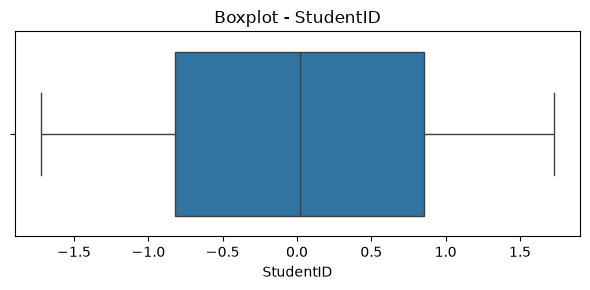

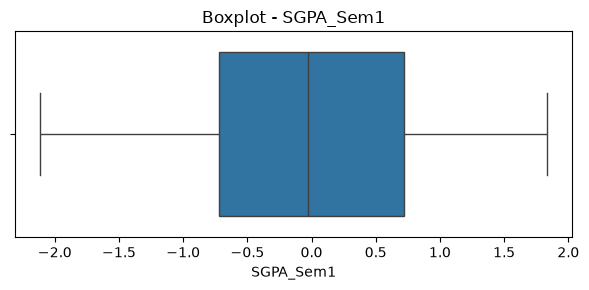

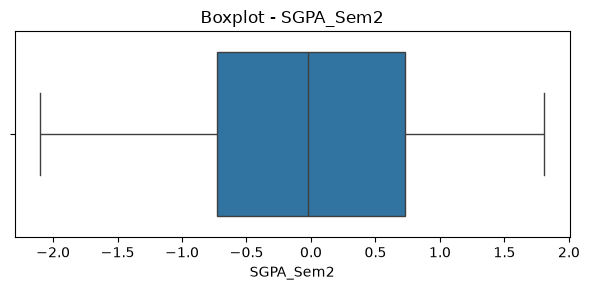

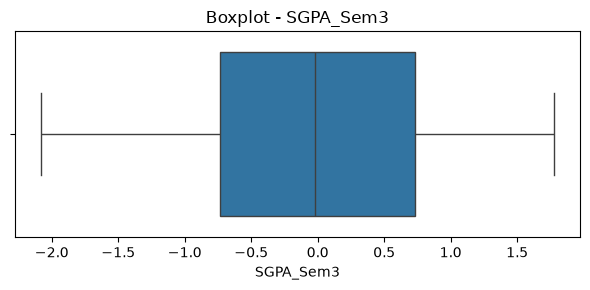

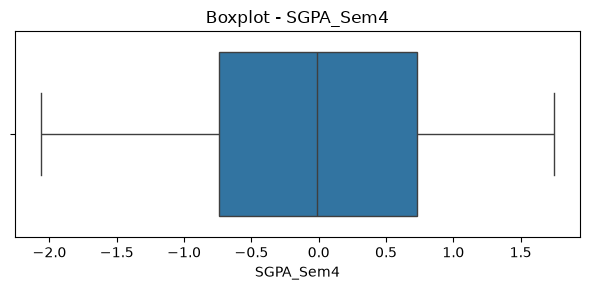

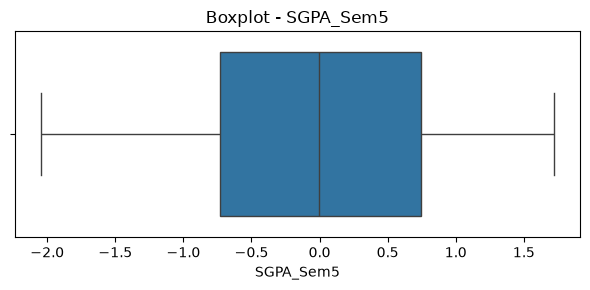

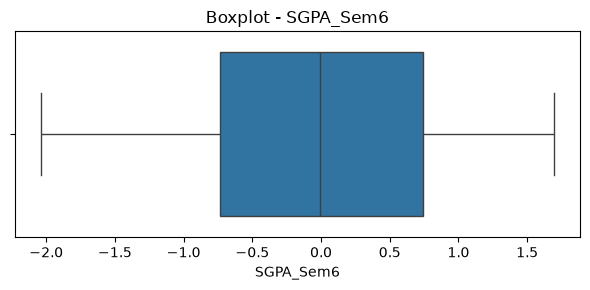

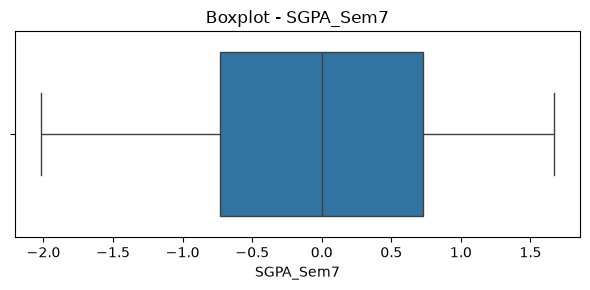

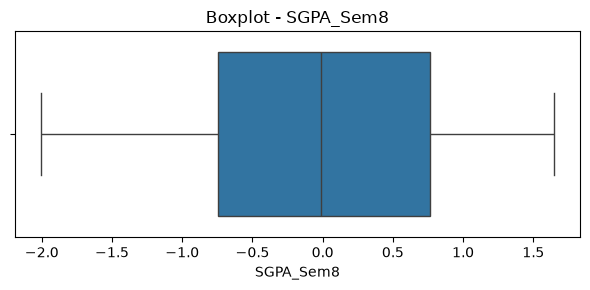

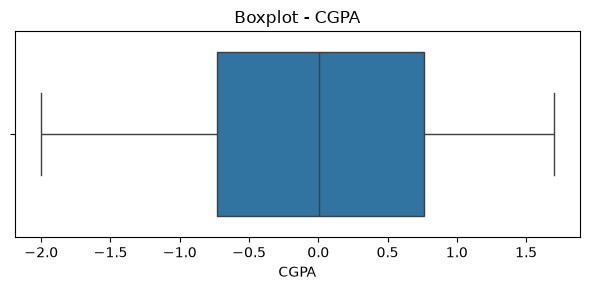

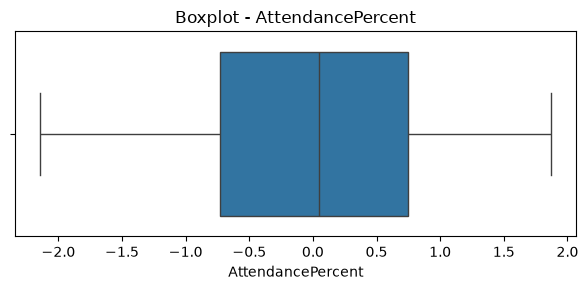

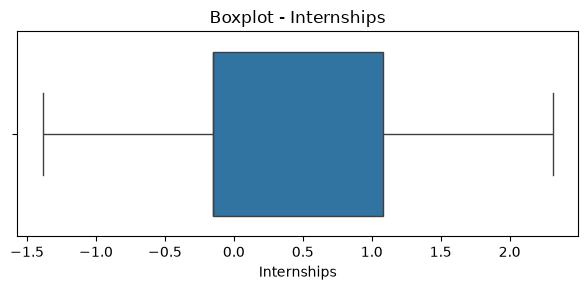

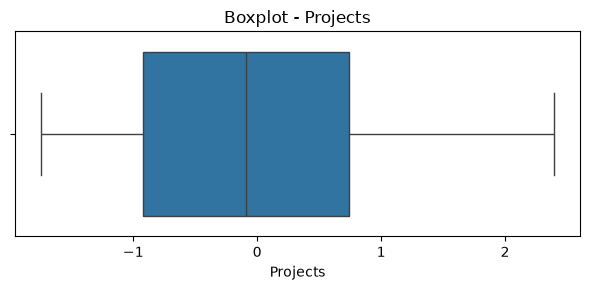

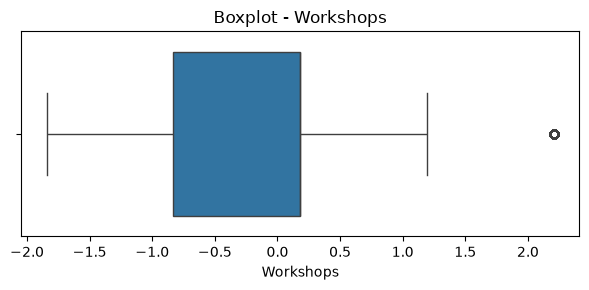

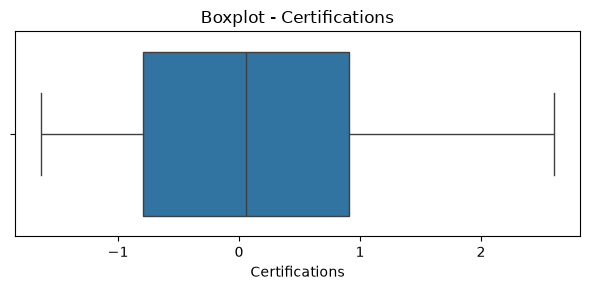

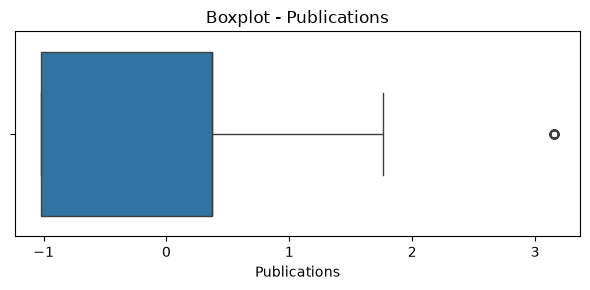

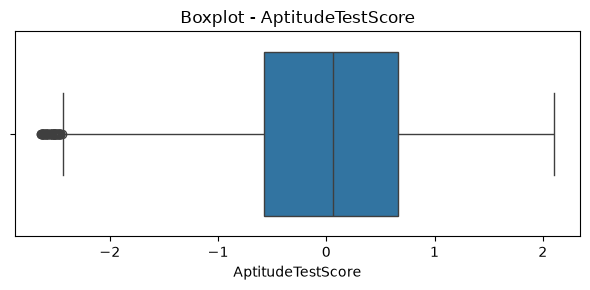

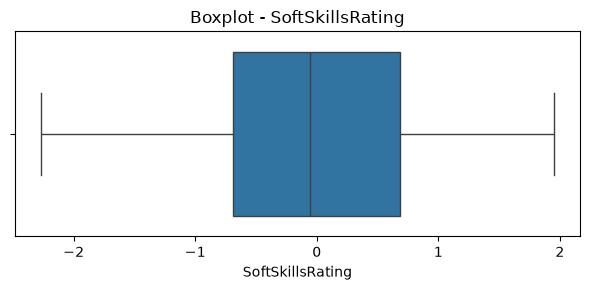

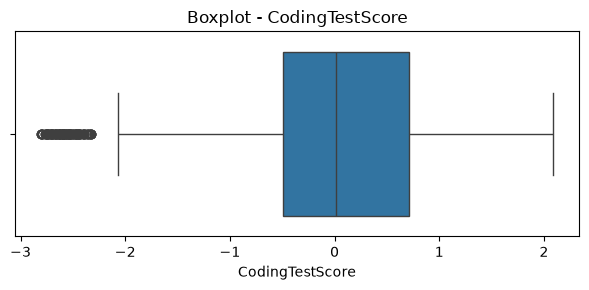

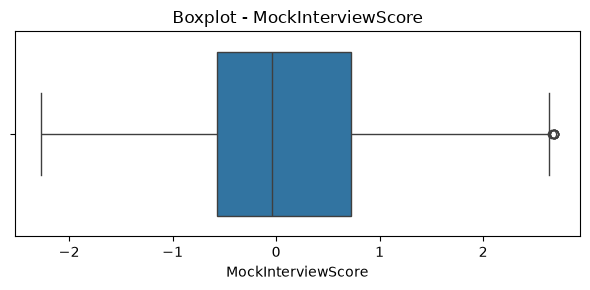

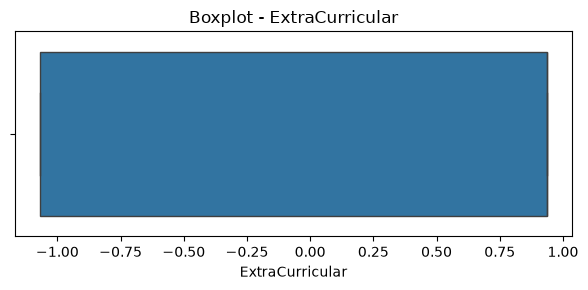

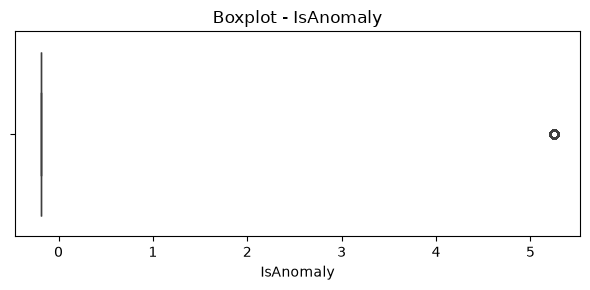

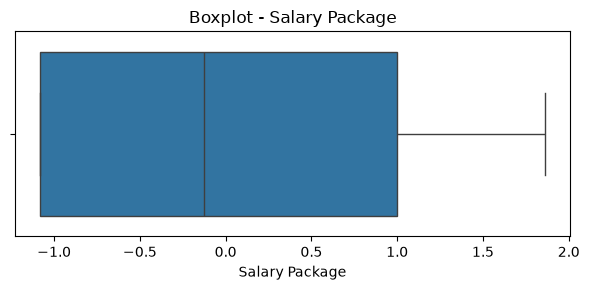

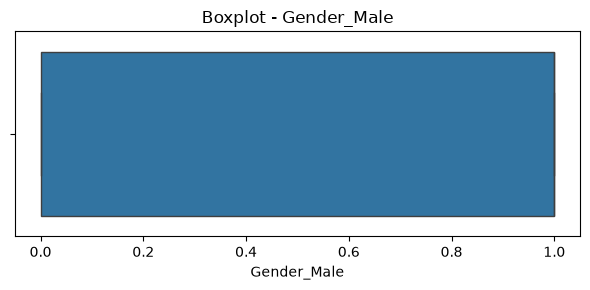

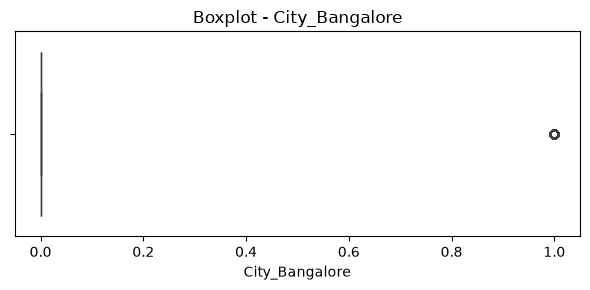

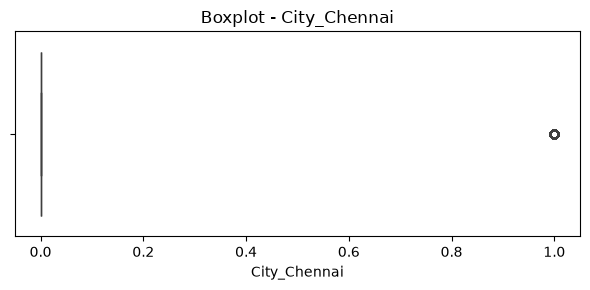

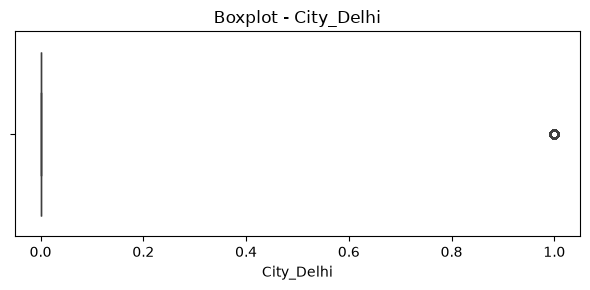

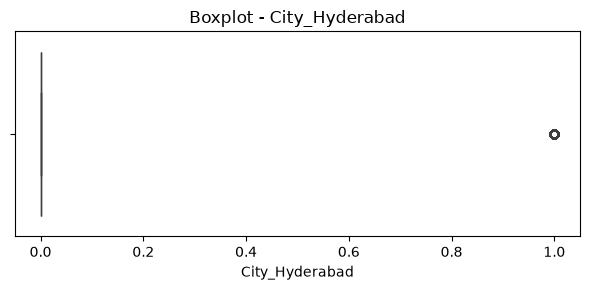

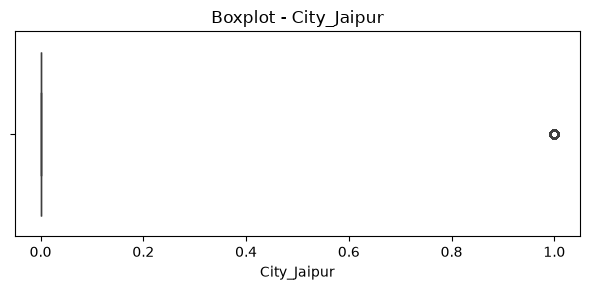

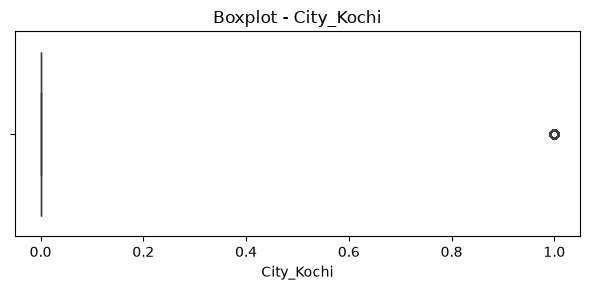

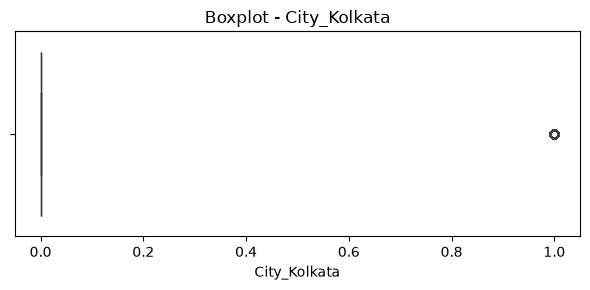

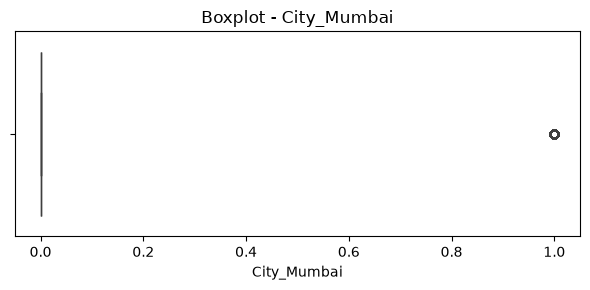

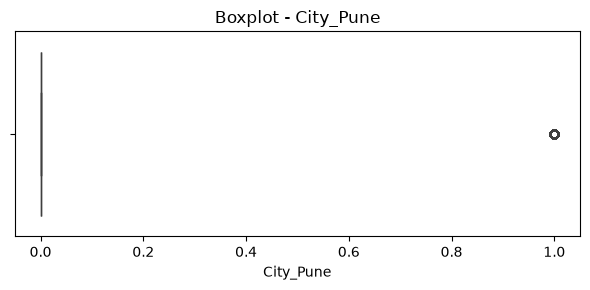

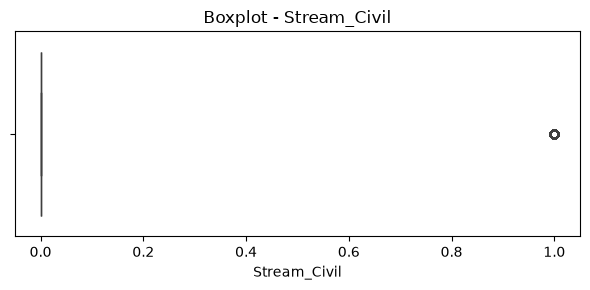

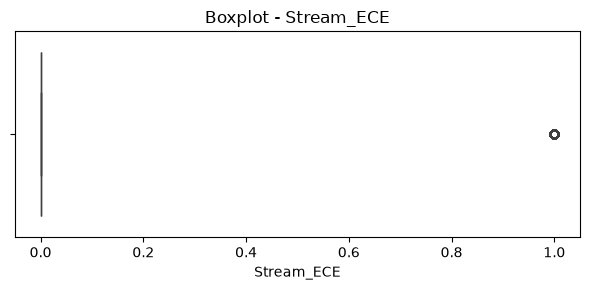

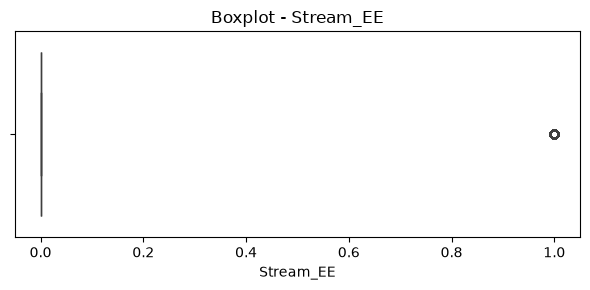

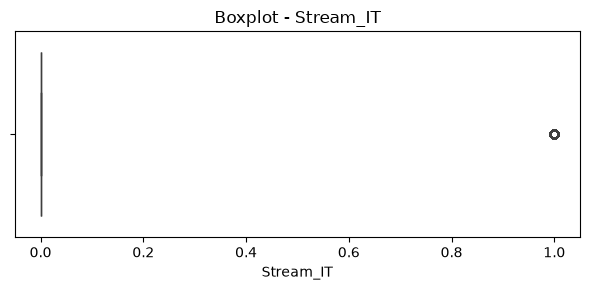

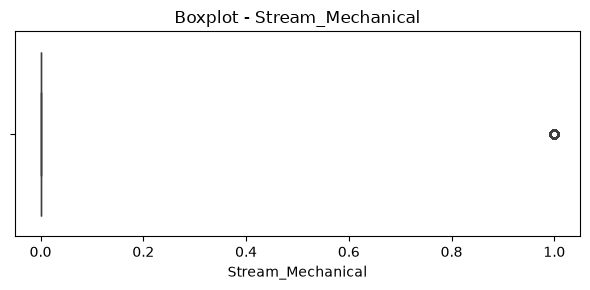

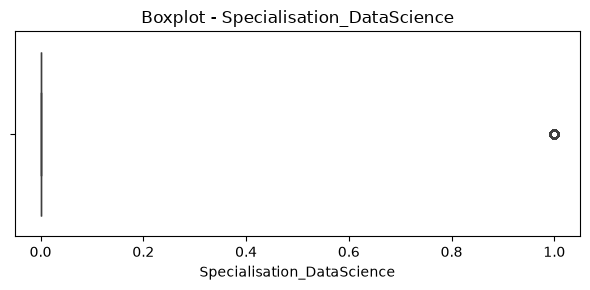

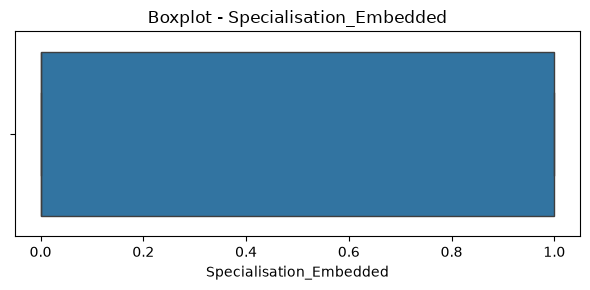

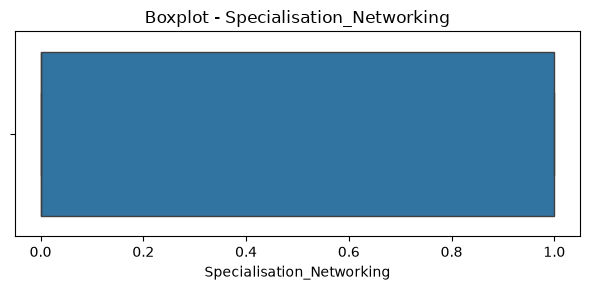

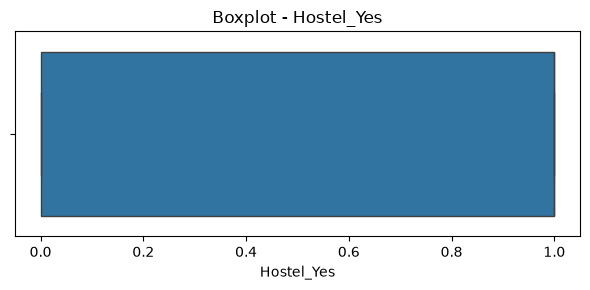

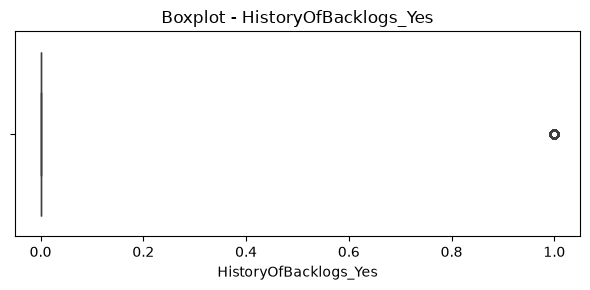

In [71]:
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.tight_layout()
    plt.show()

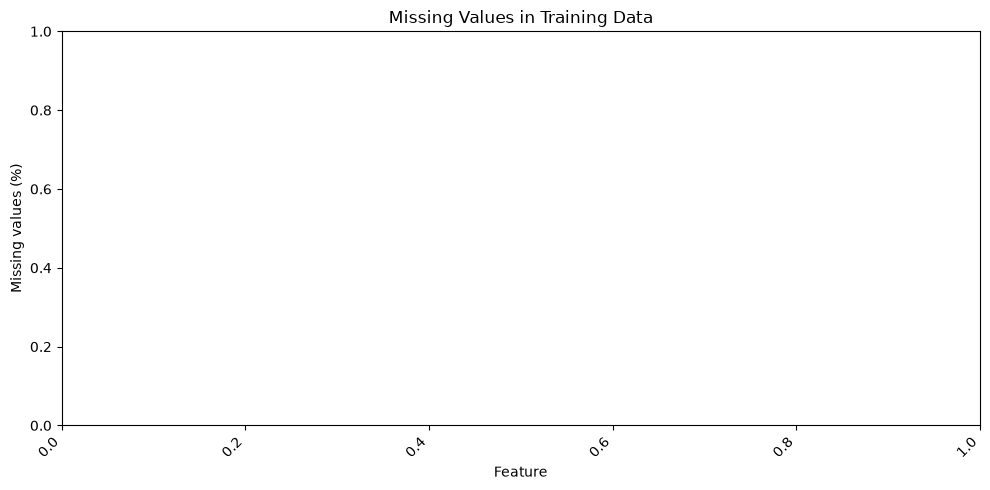

In [72]:
# ============================================================
# 8A. MISSING-VALUE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing %"]
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Feature")
plt.ylabel("Missing values (%)")
plt.title("Missing Values in Training Data")
plt.tight_layout()
plt.show()


# 9. CHECK THE EFFECT OF ROW DELETION

Before choosing deletion, measure how many training rows would be lost.

If a large percentage of students are removed, imputation is usually preferable.

The slides show that listwise deletion can result in substantial data loss for this dataset.

## NOTE: We are not deleting actually 

In [73]:
# ============================================================
# 9. LISTWISE DELETION CHECK
# ============================================================

rows_before = len(X_train)

X_train_without_missing = X_train.dropna()

rows_after = len(X_train_without_missing)

loss = rows_before - rows_after
loss_percent = loss / rows_before * 100

print("Rows before deletion:", rows_before)
print("Rows after deletion :", rows_after)
print("Rows lost           :", loss)
print("Percentage lost     :", round(loss_percent, 2), "%")


Rows before deletion: 8000
Rows after deletion : 8000
Rows lost           : 0
Percentage lost     : 0.0 %


In [74]:
X_train.shape

(8000, 1)

# 10. MEDIAN IMPUTATION FOR NUMERICAL FEATURES

For numerical missing values, the slides discuss mean and median imputation.

We use **median imputation** in the main workflow because the median is less affected by outliers and skewed values.

### Important

We calculate the median using **X_train only**.

Then we use those same medians for X_test.

We do not calculate a separate median for the test set.


In [75]:
# ============================================================
# 10. MEDIAN IMPUTATION
# ============================================================

numeric_cols = ["AptitudeTestScore"]

numeric_imputer = SimpleImputer(strategy="median")

# STEP 1: Learn median ONLY from training data
X_train_num = pd.DataFrame(
    numeric_imputer.fit_transform(X_train[numeric_cols]),
    columns=numeric_cols,
    index=X_train.index
)

# STEP 2: Apply the SAME training median to test data
X_test_num = pd.DataFrame(
    numeric_imputer.transform(X_test[numeric_cols]),
    columns=numeric_cols,
    index=X_test.index
)

print("Missing numerical values after imputation:")
print("Training:", X_train_num.isna().sum().sum())
print("Test    :", X_test_num.isna().sum().sum())


Missing numerical values after imputation:
Training: 0
Test    : 0


In [76]:
X_train_num.shape

(8000, 1)

# 11. MISSING-INDICATOR FEATURES

Imputation replaces a missing value, but sometimes the fact that it was missing is itself useful information.

Example:

```text
AptitudeTestScore = missing
```

After imputation:

```text
AptitudeTestScore = median
```

The model may not know that the original value was missing.

A missing indicator preserves that information:

```text
0 → value was originally present
1 → value was originally missing
```


In [77]:
''' # ============================================================
# 11. MISSING INDICATORS
# ============================================================

missing_numeric_cols = [
    col for col in numeric_cols
    if X_train[col].isna().any()
]

print("Numerical columns with missing values:")
print(missing_numeric_cols)

for col in missing_numeric_cols:
    X_train_num[col + "_missing"] = (
        X_train[col].isna().astype(int)
    )

    X_test_num[col + "_missing"] = (
        X_test[col].isna().astype(int)
    )

print("\nMissing indicators created.") '''


' # ============================================================\n# 11. MISSING INDICATORS\n# ============================================================\n\nmissing_numeric_cols = [\n    col for col in numeric_cols\n    if X_train[col].isna().any()\n]\n\nprint("Numerical columns with missing values:")\nprint(missing_numeric_cols)\n\nfor col in missing_numeric_cols:\n    X_train_num[col + "_missing"] = (\n        X_train[col].isna().astype(int)\n    )\n\n    X_test_num[col + "_missing"] = (\n        X_test[col].isna().astype(int)\n    )\n\nprint("\nMissing indicators created.") '

In [78]:
X_train_num

,AptitudeTestScore
9254,-0.171623
1561,-0.232644
1670,-1.412396
6087,-1.290353
6669,1.055591
...,...
5734,-0.232644
5191,0.058904
5390,1.177634
860,-0.375028


In [79]:
X_train_num.shape

(8000, 1)

# 12. CATEGORICAL FEATURES: ORDINAL VS NOMINAL

The slides distinguish two types.

### Ordinal categorical features

There is a meaningful order.

Example:

```text
Tier 1 < Tier 2 < Tier 3
```

Use **ordinal encoding**.

### Nominal categorical features

There is no meaningful order.

Example:

```text
CSE, ECE, EEE
```

Use **one-hot encoding**.

Do not blindly convert nominal categories into 0, 1, 2 because that can create a false ranking.


In [80]:
# ============================================================
# 12.A DEFINE ORDINAL AND NOMINAL FEATURES
# ============================================================

# These are the ordinal columns identified in the slides.
ordinal_cols = [
    col for col in ["CollegeTier", "CGPA_Tier"]
    if col in X_train.columns
]

# All remaining categorical columns are treated as nominal.
nominal_cols = [
    col for col in categorical_cols
    if col not in ordinal_cols
]

print("Ordinal columns:")
print(ordinal_cols)

print("\nNominal columns:")
print(nominal_cols)


Ordinal columns:
[]

Nominal columns:
[]


In [81]:
for col in nominal_cols:
    print(f"\n{col}")
    print(X_train[col].unique())

In [82]:

# ============================================================
# 12B. ONE-HOT ENCODING FOR NOMINAL FEATURES
# ============================================================

from sklearn.preprocessing import OneHotEncoder

# Drop the first category of EACH nominal variable.
# This gives K-1 dummy variables for a variable having K categories.
# It helps avoid the dummy-variable trap / perfect multicollinearity.

nominal_encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# ------------------------------------------------------------
# FIT ON X_train AND TRANSFORM X_train
# ------------------------------------------------------------

nominal_encoded_train = nominal_encoder.fit_transform(
    X_train[nominal_cols]
)

nominal_feature_names = (
    nominal_encoder.get_feature_names_out(nominal_cols)
)

nominal_encoded_train = pd.DataFrame(
    nominal_encoded_train,
    columns=nominal_feature_names,
    index=X_train.index
)

print("\nOne-hot encoded X_train:")
display(nominal_encoded_train.head())

print("\nEncoded nominal feature names:")
print(nominal_feature_names.tolist())

print("\nNumber of nominal features after encoding:",
      nominal_encoded_train.shape[1])


# ------------------------------------------------------------
# TRANSFORM X_test USING THE SAME ENCODER
# ------------------------------------------------------------

nominal_encoded_test = nominal_encoder.transform(
    X_test[nominal_cols]
)

nominal_encoded_test = pd.DataFrame(
    nominal_encoded_test,
    columns=nominal_feature_names,
    index=X_test.index
)

print("\nOne-hot encoded X_test:")
display(nominal_encoded_test.head())

print("\nX_train nominal encoded shape:",
      nominal_encoded_train.shape)

print("X_test nominal encoded shape:",
      nominal_encoded_test.shape)


One-hot encoded X_train:


""
9254
1561
1670
6087
6669



Encoded nominal feature names:
[]

Number of nominal features after encoding: 0

One-hot encoded X_test:


""
6252
4684
1731
4742
4521



X_train nominal encoded shape: (8000, 0)
X_test nominal encoded shape: (2000, 0)


In [83]:
nominal_encoded_train.shape

(8000, 0)

# 13. LABEL ENCODING — TARGET

`LabelEncoder` is used here for the **target variable**.

Example:

```text
Not Placed → 0
Placed     → 1
```

We fit the encoder on `y_train` and use the same mapping on `y_test`.

We do not use `LabelEncoder` blindly on nominal input features.



In [84]:
# ============================================================
# 13. LABEL ENCODE THE TARGET
# ============================================================

label_encoder = LabelEncoder()

# Learn target mapping from training labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Apply the same mapping to test labels
y_test_encoded = label_encoder.transform(y_test)

print("Original target classes:")
print(label_encoder.classes_)

print("\nEncoded target values:")
print(np.unique(y_train_encoded))


ValueError: y contains previously unseen labels: [np.float64(-0.7122887887030364), np.float64(-0.6964397357512364), np.float64(-0.6930435101187079), np.float64(-0.6873831340644936), np.float64(-0.6556850281608939), np.float64(-0.6432322008416226), np.float64(-0.633043523944037), np.float64(-0.6013454180404372), np.float64(-0.5617227856609375), np.float64(-0.5560624096067233), np.float64(-0.5549303343958804), np.float64(-0.5345529806007091), np.float64(-0.4937982730103665), np.float64(-0.4847416713236238), np.float64(-0.4802133704802525), np.float64(-0.4643643175284525), np.float64(-0.4632322423176097), np.float64(-0.4473831893658098), np.float64(-0.4394586628899098), np.float64(-0.4202133843055814), np.float64(-0.4145530082513672), np.float64(-0.3964398048778816), np.float64(-0.3771945262935532), np.float64(-0.3658737741851247), np.float64(-0.3070058632212966), np.float64(-0.0375719630406986), np.float64(-0.0307795117756417), np.float64(-0.0217229100888989), np.float64(0.00884312060385

# 14. HANDLE MISSING CATEGORICAL VALUES

For categorical columns with missing values, use the most frequent category.

Again, learn the most frequent category from the training data only.


In [ ]:


# ============================================================
# 14. CATEGORICAL IMPUTATION
# ============================================================

# ----- Ordinal columns -----
if ordinal_cols:
    ordinal_imputer = SimpleImputer(strategy="most_frequent")

    X_train_ord = pd.DataFrame(
        ordinal_imputer.fit_transform(X_train[ordinal_cols]),
        columns=ordinal_cols,
        index=X_train.index
    )

    X_test_ord = pd.DataFrame(
        ordinal_imputer.transform(X_test[ordinal_cols]),
        columns=ordinal_cols,
        index=X_test.index
    )
else:
    X_train_ord = pd.DataFrame(index=X_train.index)
    X_test_ord = pd.DataFrame(index=X_test.index)


# ----- Nominal columns -----
if nominal_cols:
    nominal_imputer = SimpleImputer(strategy="most_frequent")

    X_train_nom = pd.DataFrame(
        nominal_imputer.fit_transform(X_train[nominal_cols]),
        columns=nominal_cols,
        index=X_train.index
    )

    X_test_nom = pd.DataFrame(
        nominal_imputer.transform(X_test[nominal_cols]),
        columns=nominal_cols,
        index=X_test.index
    )
else:
    X_train_nom = pd.DataFrame(index=X_train.index)
    X_test_nom = pd.DataFrame(index=X_test.index)

print("Categorical imputation completed.")


Categorical imputation completed.


In [ ]:
X_train_num.shape
       

(40000, 23)

In [ ]:
X_train_ord.shape       
       

(40000, 2)

In [ ]:
nominal_encoded_train.shape

(40000, 20)

# 15. COMBINE THE PREPROCESSED FEATURES

Now combine:

1. Imputed numerical features
3. Ordinal encoded features
3. One-hot encoded features

The target remains separate.



In [ ]:
# ============================================================
# 15. COMBINE FEATURES
# ============================================================

X_train_processed = pd.concat(
    [
        X_train_num,
        X_train_ord,        
        nominal_encoded_train

    ],
    axis=1
)

X_test_processed = pd.concat(
    [
        X_test_num,
        X_test_ord,        
        nominal_encoded_test
    ],
    axis=1
)

print("X_train processed shape:", X_train_processed.shape)
print("X_test processed shape :", X_test_processed.shape)


X_train processed shape: (40000, 45)
X_test processed shape : (10000, 45)


# 16. FEATURE SCALING

### Does scaling come last?

For this teaching workflow, **yes: scaling comes after missing-value handling and categorical encoding, and immediately before the ML model**.

But scaling is applied only to the **true numerical features** that need it.

For Logistic Regression, StandardScaler is useful because the model is sensitive to feature scale.

We do **not** scale:

- the target
- one-hot 0/1 variables
- missing-indicator 0/1 variables

### Standardization
$$Z = \frac{X - \mu}{\sigma}$$


The mean and standard deviation are learned from `X_train` only.


In [ ]:
# ============================================================
# 17. STANDARD SCALING
# ============================================================

# Only scale the original numerical feature columns.
# Missing indicators and one-hot columns remain 0/1.
scale_cols = [
    col for col in numeric_cols
    if col in X_train_processed.columns
]

scaler = StandardScaler()

# LEARN mean and standard deviation from training data only
X_train_processed[scale_cols] = scaler.fit_transform(
    X_train_processed[scale_cols]
)

# APPLY the same training statistics to test data
X_test_processed[scale_cols] = scaler.transform(
    X_test_processed[scale_cols]
)

print("Standard scaling completed.")


Standard scaling completed.


In [ ]:
# Get feature names after preprocessing
feature_names = X_train_processed.columns.tolist()

print("Number of features:", len(feature_names))
print("\nFeature names:")
print(feature_names)



Number of features: 45

Feature names:
['StudentID', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'IsAnomaly', 'Salary Package', 'CollegeTier', 'CGPA_Tier', 'Gender_Male', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Jaipur', 'City_Kochi', 'City_Kolkata', 'City_Mumbai', 'City_Pune', 'Stream_Civil', 'Stream_ECE', 'Stream_EE', 'Stream_IT', 'Stream_Mechanical', 'Specialisation_DataScience', 'Specialisation_Embedded', 'Specialisation_Networking', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']


## 18. OPTIONAL: SAVE THE PROCESSED DATA

The following saves the numerical matrix produced by the preprocessing pipeline. The column names are generated automatically because One-Hot Encoding creates new columns.

In [ ]:
import pandas as pd

X_train_processed_df = pd.DataFrame(X_train_processed)

X_test_processed_df = pd.DataFrame(X_test_processed)

X_train_processed_df.to_csv(r"C:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\data\placement_predict_50k Dataset_final.csv", index=False)
X_test_processed_df.to_csv(r"C:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\data\placement_predict_50k Dataset_final.csv", index=False)

In [ ]:
y_train.to_csv(r"C:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\data\placement_predict_50k Dataset_final.csv_train.csv", index=False)
y_test.to_csv(r"C:\Users\Varshith\OneDrive\Desktop\KLH\2year\Machine Learning\Placement-Prediction-System\data\placement_predict_50k Dataset_final.csv_test.csv", index=False)

In [ ]:
y_test.shape

(10000,)

In [ ]:
y_train.shape

(40000,)

In [ ]:
# ============================================================
# 18. CHECK TRAINING MEAN AND STANDARD DEVIATION
# ============================================================

scaling_check = pd.DataFrame({
    "Training Mean": X_train_processed[scale_cols].mean(),
    "Training Std": X_train_processed[scale_cols].std()
})

display(scaling_check.round(3))


,Training Mean,Training Std
StudentID,0.0,1.0
SGPA_Sem1,-0.0,1.0
SGPA_Sem2,0.0,1.0
SGPA_Sem3,0.0,1.0
SGPA_Sem4,0.0,1.0
SGPA_Sem5,-0.0,1.0
SGPA_Sem6,0.0,1.0
SGPA_Sem7,-0.0,1.0
SGPA_Sem8,0.0,1.0
CGPA,-0.0,1.0


# 21. FINALT FLOW

```text
                 RAW DATA
                    ↓
             Remove Duplicates
                    ↓
              Separate X / y
                    ↓
             Train/Test Split
                    ↓
          ┌─────────┴─────────┐
          ↓                   ↓
     TRAINING DATA         TEST DATA
          ↓                   ↓
 Missing-value analysis       │
          ↓                   │
 Numerical → Median           │
 Categorical → Mode           │
          ↓                   │
 Missing indicators            │
          ↓                   │
 Ordinal encoding              │
          ↓                   │
 One-hot encoding              │
          ↓                   │
 Numerical scaling             │
          ↓                   │
          └─────────┬─────────┘
                    ↓
               ML MODEL
                    ↓
               EVALUATION
```



## 15. OPTIONAL: SAVE THE PROCESSED DATA

The following saves the numerical matrix produced by the preprocessing pipeline. The column names are generated automatically because One-Hot Encoding creates new columns.

In [ ]:
# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

X_train_processed_df.to_csv('X_train_processed.csv', index=False)
X_test_processed_df.to_csv('X_test_processed.csv', index=False)

pd.Series(y_train_encoded, name='PlacementStatus').to_csv(
    'y_train_encoded.csv', index=False
)
pd.Series(y_test_encoded, name='PlacementStatus').to_csv(
    'y_test_encoded.csv', index=False
)

print('Processed training and testing files saved successfully!')

NameError: name 'preprocessor' is not defined